# Potato Disease Detection using Deep Learning

## Project Overview

This project uses a Convolutional Neural Network (CNN) to classify potato leaf images into three classes:

- Healthy
- Early Blight
- Late Blight

**Dataset:** PlantVillage (Potato subset)

**Framework:** TensorFlow / Keras

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


## Loading the Dataset

In [2]:
IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS = 3

dataset = tf.keras.utils.image_dataset_from_directory(
    "dataset",
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

class_names = dataset.class_names

print("Classes:", class_names)
print("Total Batches:", len(dataset))

Found 2152 files belonging to 3 classes.
Classes: ['Potato_Early_blight', 'Potato_Late_blight', 'Potato_healthy']
Total Batches: 68


# Visualizing Sample Images

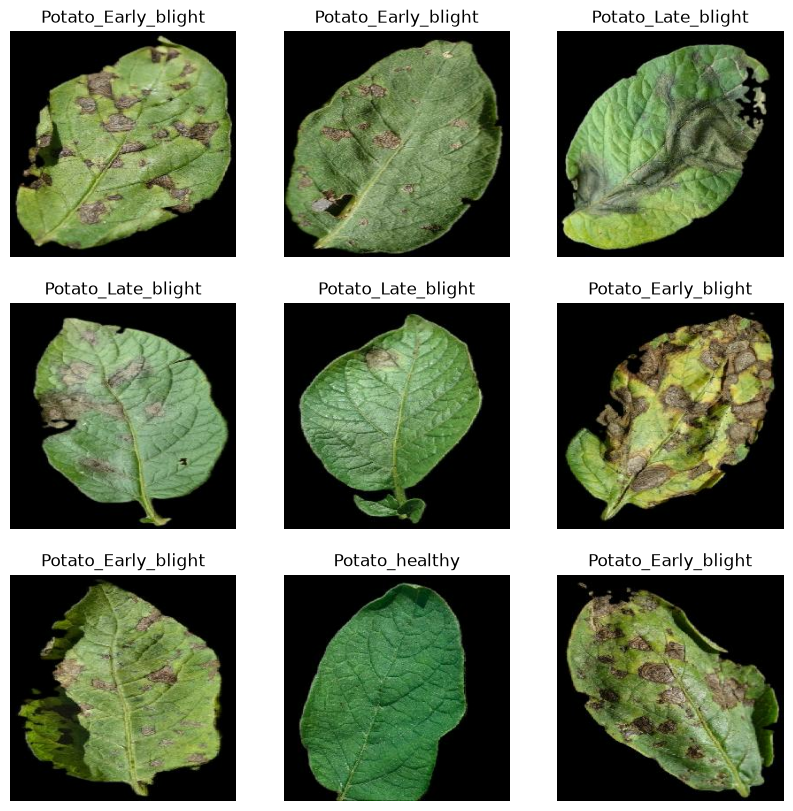

In [3]:
plt.figure(figsize=(10, 10))

for images, labels in dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

# Splitting the Dataset

We split the dataset into three parts:

- **Training Set (80%)** – Used to train the CNN.
- **Validation Set (10%)** – Used during training to monitor performance.
- **Test Set (10%)** – Used only after training to evaluate the final model.

In [4]:
def get_dataset_partitions_tf(
    ds,
    train_split=0.8,
    val_split=0.1,
    test_split=0.1,
    shuffle=True,
    shuffle_size=10000,
):

    assert (train_split + val_split + test_split) == 1

    ds_size = len(ds)

    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)

    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)

    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)

    return train_ds, val_ds, test_ds

In [5]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

print("Training batches:", len(train_ds))
print("Validation batches:", len(val_ds))
print("Testing batches:", len(test_ds))

Training batches: 54
Validation batches: 6
Testing batches: 8


## Data Augmentation

Data augmentation artificially increases the diversity of the training dataset by applying random transformations.

This helps the model generalize better to real-world images taken from different angles and orientations

In [6]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
])

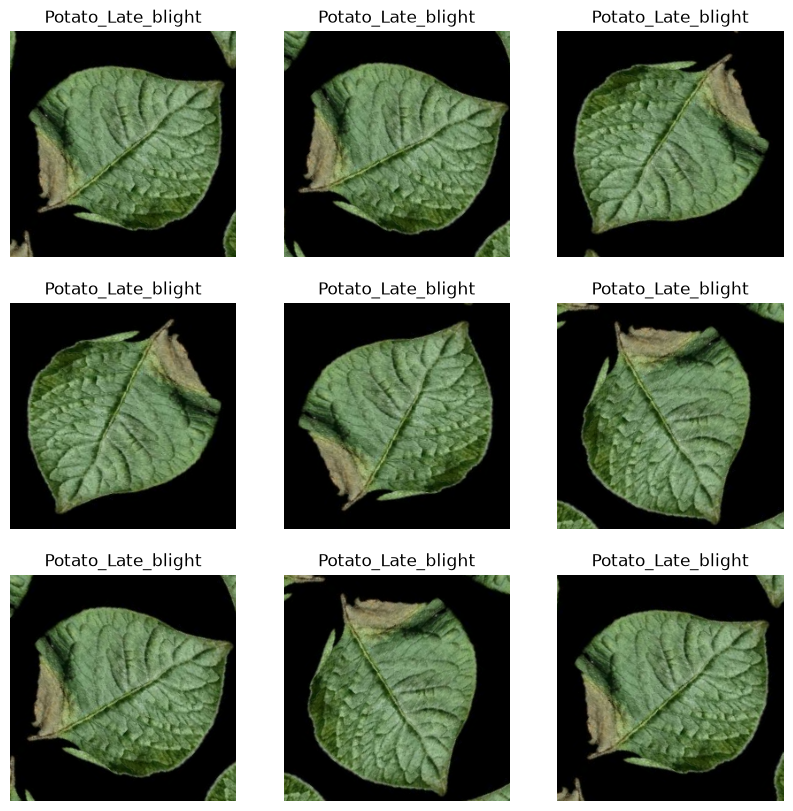

In [7]:
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    first_image = images[0]
    first_label = labels[0]

    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
        plt.imshow(augmented_image[0].numpy().astype("uint8"))
        plt.title(class_names[first_label])
        plt.axis("off")

## Optimizing the Data Pipeline

We use:

- **Cache** – Stores the dataset in memory after the first epoch.
- **Prefetch** – Loads the next batch while the current one is being processed.

These optimizations improve training speed.

In [8]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)

val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

## Building CNN


In [9]:
INPUT_SHAPE = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
N_CLASSES = 3

In [11]:
model = tf.keras.Sequential([

    # Resize all images
    tf.keras.layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),

    # Normalize pixels (0-255 → 0-1)
    tf.keras.layers.Rescaling(1./255),

    # Data Augmentation
    data_augmentation,

    # CNN Block 1
    tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),

    # CNN Block 2
    tf.keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),

    # CNN Block 3
    tf.keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),

    # CNN Block 4
    tf.keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),

    # CNN Block 5
    tf.keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),

    # CNN Block 6
    tf.keras.layers.Conv2D(64, kernel_size=(3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),

    # Convert feature maps into one vector
    tf.keras.layers.Flatten(),

    # Dense Layer
    tf.keras.layers.Dense(64, activation='relu'),

    # Output Layer
    tf.keras.layers.Dense(N_CLASSES, activation='softmax')

])

In [12]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

In [13]:
EPOCHS = 50

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/50


D:\SOC_Kloris\Potato-Disease-Detection\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


54/54 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.6021 - loss: 0.7516 - val_accuracy: 0.8333 - val_loss: 0.3555
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 85s 2s/step - accuracy: 0.8216 - loss: 0.3820 - val_accuracy: 0.8802 - val_loss: 0.2520
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.8744 - loss: 0.2941 - val_accuracy: 0.8906 - val_loss: 0.2739
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.9026 - loss: 0.2451 - val_accuracy: 0.9062 - val_loss: 0.2113
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.9020 - loss: 0.2570 - val_accuracy: 0.8490 - val_loss: 0.3509
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.8908 - loss: 0.2619 - val_accuracy: 0.9115 - val_loss: 0.2135
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.9067 - loss: 0.2305 - val_accuracy: 0.8177 - val_loss: 0.3847
Epoch 8/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.9090 - loss: 0.2463 - val_accuracy: 0.9062 - val_loss: 0.2690
Ep

## Accuracy Plot


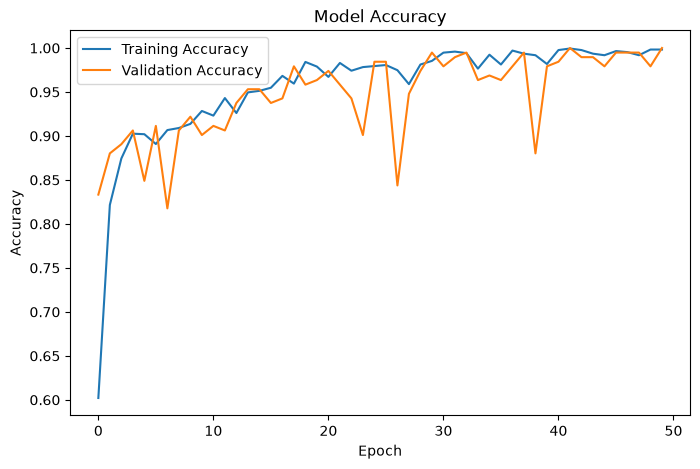

In [14]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

# Plot Loss

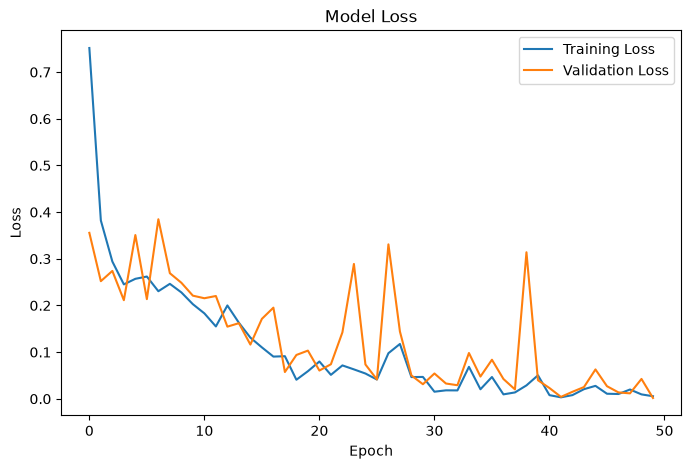

In [15]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

# Evaluation

In [16]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss :", test_loss)
print("Test Accuracy :", test_accuracy)

8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 482ms/step - accuracy: 1.0000 - loss: 9.2009e-04
Test Loss : 0.0009200907661579549
Test Accuracy : 1.0


# Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


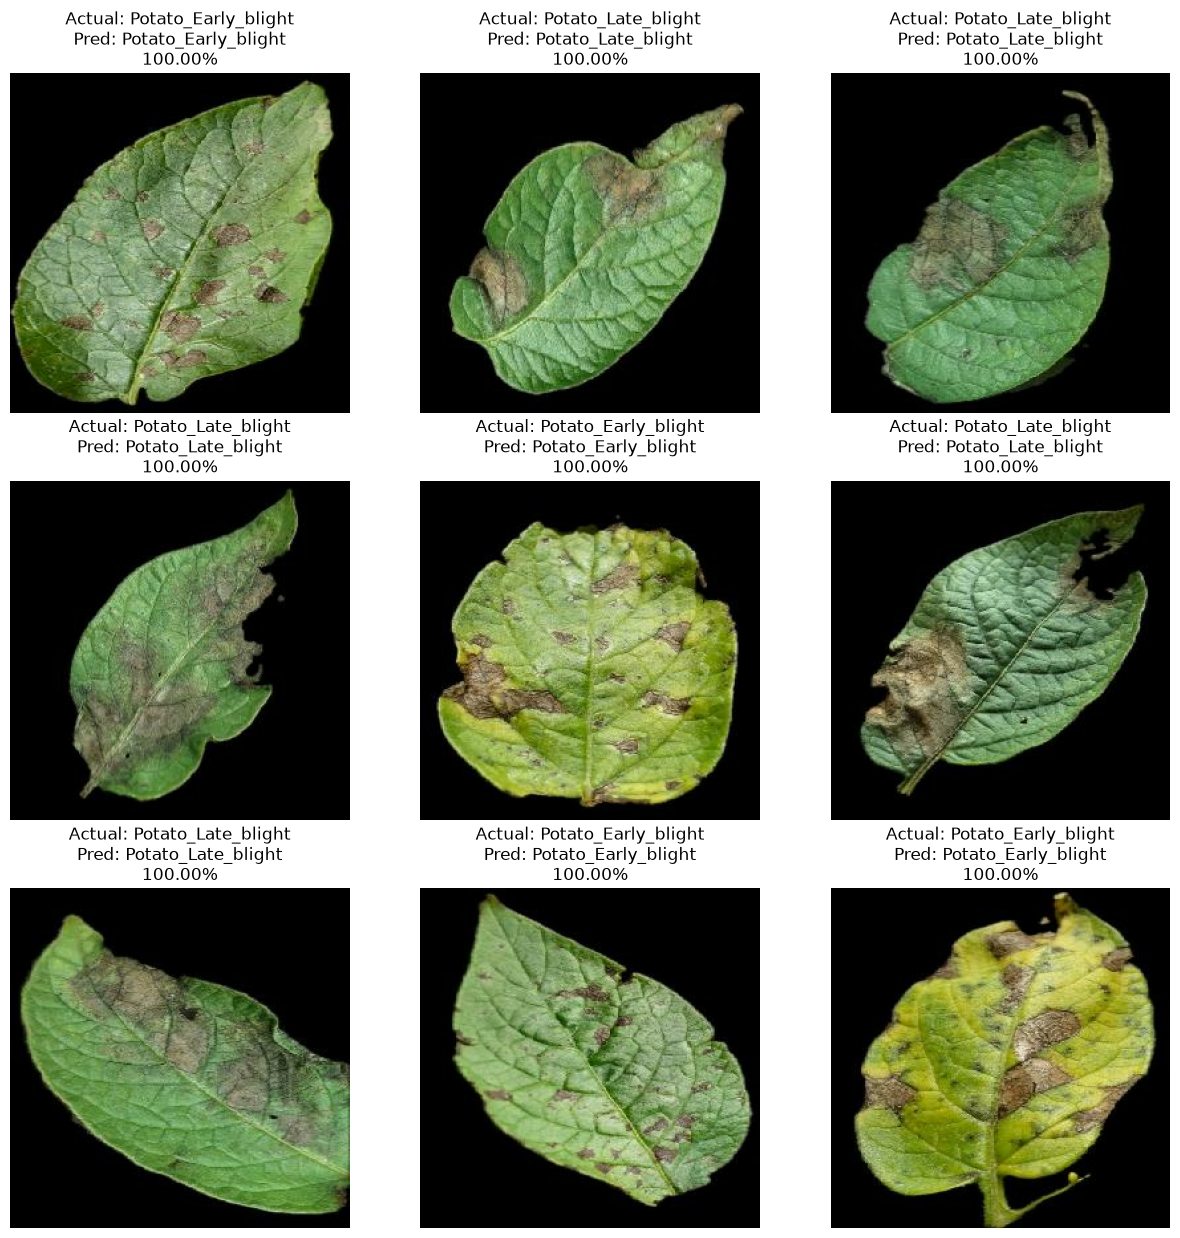

In [17]:
import numpy as np

plt.figure(figsize=(15,15))

for images, labels in test_ds.take(1):

    predictions = model.predict(images)
    predicted_classes = np.argmax(predictions, axis=1)

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        actual = class_names[labels[i]]
        predicted = class_names[predicted_classes[i]]

        confidence = np.max(predictions[i]) * 100

        plt.title(
            f"Actual: {actual}\nPred: {predicted}\n{confidence:.2f}%"
        )

        plt.axis("off")

# Saving the Model

In [18]:
import os

MODEL_PATH = "models/1"

os.makedirs(MODEL_PATH, exist_ok=True)

model.export(MODEL_PATH)

INFO:tensorflow:Assets written to: models/1\assets


INFO:tensorflow:Assets written to: models/1\assets


Saved artifact at 'models/1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='keras_tensor_3')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  1878950218064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1878950223632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1878953439888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1878953434896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1876951336912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1876951337680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1876951338256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1876951339216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1876951338640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1876951339600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1876951339408: TensorSpec(shape=(), dtyp